In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#setup for poor housing conditions
housing = pd.read_csv("poorhousingconditions.csv")

def filterLess (x, column, filtVal):
    abc = x[x[column].astype(float) >= filtVal]
    return abc

tenPercent = filterLess(housing, 'PPoorCon', .1)
df = tenPercent.assign(Neighborhood= [
    'North Fayette', 'North Braddock', 'North Braddock',
    'North Braddock', 'Rankin', 'McKeesport',
    'McKeesport', 'McKeesport', 'Wilkinsburg',
    'Wilkinsburg', 'McKeesport', 'Forward',
    'Wilmerding', 'Duquense', 'Homestead',
    'Frazer Township', 'Harrison Township', 'Wilkinsburg',
    'Braddock', 'Spring Garden', 'Turtle Creek',
    'Etna', 'Clairton', 'Duquense'
    ])


# Best and Worst Neighborhoods in Pittsburgh

### URL's to Data Sets used
*  https://data.wprdc.org/dataset/allegheny-county-poor-condition-residential-parcel-rates
*

##### We got our datasets from the WPRDC website.  They contian information on poor housing conditoins...  in the city of Pittsburgh.

## Intoduction

## Metric

#### To determine which Pittsburgh neighborhoods are the best and worst, we judged communities based on the standard of living thier residents have.  Factoring into our calculation of standard of living are poor housing conditoins, police incidents, and air quality.  If less than 10% of people in a neighborhood had poor housing conditions, that community was automatically removed from being considered for best neighborhood.  

### Poor Housing Conditoins

In [4]:
display(df['PPoorCon'].describe())
df.sort_values(by=['TRACT']).set_index('Neighborhood')


count    24.000000
mean      0.154636
std       0.050970
min       0.100973
25%       0.112580
50%       0.129688
75%       0.204757
max       0.256312
Name: PPoorCon, dtype: float64

,TRACT,PPoorCon
Neighborhood,,
Spring Garden,241200,0.126110
Harrison Township,401200,0.124040
Frazer Township,405000,0.116105
Etna,425000,0.106359
Homestead,483800,0.111111
Duquense,486800,0.145397
Duquense,486900,0.100973
Clairton,492700,0.107236
Forward,495000,0.113070


In [2]:
quantity = df['Neighborhood'].value_counts()
avg = df.groupby('Neighborhood').mean()
new = avg.drop(columns=['TRACT']).rename(columns={'PPoorCon': 'AvgPPoorCon'})
new['quantity']= quantity

stupid = new.reset_index()

new

,AvgPPoorCon,quantity
Neighborhood,,
Braddock,0.143345,1
Clairton,0.107236,1
Duquense,0.123185,2
Etna,0.106359,1
Forward,0.113070,1
Frazer Township,0.116105,1
Harrison Township,0.124040,1
Homestead,0.111111,1
McKeesport,0.218043,4


#### This chart is based on a dataset from WPRDC which tracks the percentage of poor housing conditions in each census tract.  
#### It has been modified to use the neighborhood as the index, and only displays data regarding tracts with poor conditions greater than %10
#### The tracts have been grouped by neighborhood and the number of tracts within each neighborhood is represented under quantity.
#### The column labled AvgPPoorCon represents the average poor conditions in each neighborhood.  It divides the total percentage by the total number of tracts with poor conditions over %10 in each neighborhood that has a tract greater than %10. 


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),
 <a list of 16 Text xticklabel objects>)

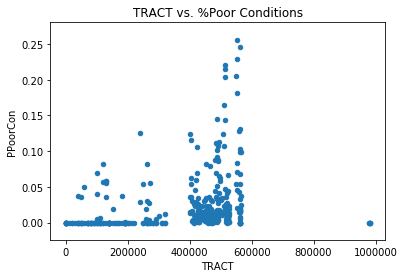

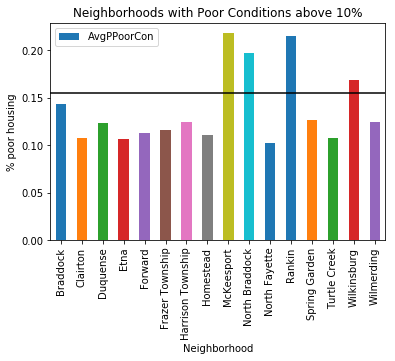

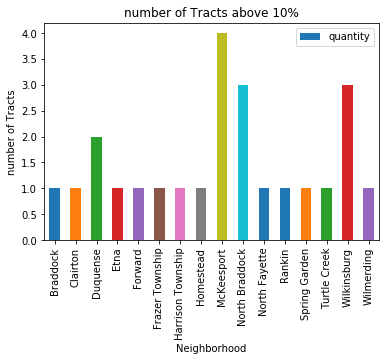

In [20]:
#plt.scatter(x=stupid['Neighborhood'], y=stupid['AvgPPoorCon'], s=stupid['quantity']*20)
#plt.xticks(rotation=90)

housing.plot(kind='scatter', x='TRACT', y='PPoorCon', title="TRACT vs. %Poor Conditions");


avgComp = new.plot.bar(y = 'AvgPPoorCon', title="Neighborhoods with Poor Conditions above 10%")
plt.axhline(df['PPoorCon'].mean(), color='k');
plt.ylabel('% poor housing')



quantityComp = new.plot.bar(y = 'quantity', title="number of Tracts above 10%")
plt.ylabel('number of Tracts')

plt.scatter(x=stupid['Neighborhood'], y=stupid['AvgPPoorCon'], s=stupid['quantity']*20)
plt.xticks(rotation=90)



#### create a markdown describing what graphs mean